# Equity champions — feature importance (train-only, clean split)

Champions from `selection_table.csv` — purged inner k-fold + 1SE, global cut **2021-10-06**.
All importance analysis uses **train data only** (post-split). The held-out 30% (post-2021-10-20) is **sealed**.

| Instrument | Group | Champion | AUC | Lower CI | Signal |
|------------|-------|----------|-----|----------|--------|
| es1s | es1s | Logistic | 0.595±0.029 | 0.567 | YES |
| nq1s | nq1s | XGB | 0.570±0.033 | 0.537 | YES |
| fesx1s | fesx1s | RF | 0.496±0.024 | 0.472 | NO |

> **fesx1s** carries no confirmed signal (lower CI < 0.50). Its importance analysis is included for contrast only — results reflect model noise rather than exploitable structure.

---
## Analysis pipeline

The same five-step sequence is applied to each instrument. All computations run on **train data only**;
the sealed 30% test set is never read here and no model is evaluated OOS.

### Step 1 — Feature clustering
Continuous features (excluding hand-assigned groups) are clustered by **Spearman distance** √(1−|ρ|)
with **Ward linkage**. The number of clusters K is chosen by silhouette score over K ∈ [2, 25].
Four groups are hand-assigned by prefix: `f4_` → F4_latent, `f5_` → F5_signal, `f8_` → F8_calendar,
`inst_` → F_instrument (pooled models only). These bypass correlation clustering.

### Step 2 — Cluster-level importance
Three importance signals per cluster, evaluated within **CPCV** (n_groups=6, k=2, embargo=1 %):

- **Clustered MDA** (headline): jointly permute all cluster members with one shared row permutation;
  N=10 repeats averaged; score AUC drop on target instrument's CPCV test slice.
  For pooled models the test slice is filtered to the target instrument before scoring.
- **Tree models** — MDI (train; sum feature_importances_ within cluster) and Group SHAP
  (TreeSHAP, tree_path_dependent, OOS slice).
- **Logistic model** — cluster |coef| sum (sum of |standardised elastic-net coefficients|
  per cluster). MDA permutes the **scaled** data (scaler fitted on outer-train fold).

A cluster is **significant** when its mean MDA drop > 1σ (cross-CPCV std).
**Rank agreement** is assessed via Kendall τ across cluster MDA / MDI / SHAP rankings
(or MDA / Coef for logistic); |τ| > 0.4 is treated as agreement.

### Step 3 — Within-cluster breakdown (top 3 clusters)
For the top 3 clusters by MDA (preferring significant clusters), individual members are ranked
by mean |SHAP| (tree) or mean |coef| (logistic). Single-feature permutation is intentionally
**not used** within a cluster — correlated members would inflate individual scores.

### Step 4 — PCA within top clusters
**PCA** (up to 3 PCs, standardised inputs) on the cluster's train submatrix.
PC1 variance interpretation tier: ≥65 % = single latent dimension; 40–65 % = dominant direction;
<40 % = genuinely multi-dimensional. Loadings reveal which members drive each component.

### Step 5 — Global per-feature view
**Tree**: mean |SHAP| per feature (averaged across CPCV paths), coloured by sign (red = positive,
blue = negative predictive direction). Also reports per-feature MDI.
**Logistic**: mean |standardised coefficient| per feature, coloured by sign.
SHAP direction reflects **model direction**, not necessarily profitable direction — the model may
learn to trade against a feature.


In [1]:
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display

BASE = Path('outputs/importance')

def show(path, width=1100):
    p = Path(path)
    if p.exists():
        display(Image(str(p), width=width))
    else:
        print(f'[missing] {p}')

def load(path):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    print(f'[missing] {p}')
    return pd.DataFrame()

def cluster_summary(inst):
    mem = load(BASE / inst / 'cluster_membership.csv')
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mem.empty or mda.empty:
        return pd.DataFrame()
    grp = (
        mem.groupby('cluster')
        .agg(
            n_members=('feature', 'count'),
            dominant_pfx=('f_prefix', lambda x: x.value_counts().index[0]),
            purity=('f_prefix', lambda x: round(x.value_counts().iloc[0] / len(x), 2)),
        )
        .reset_index()
    )
    mda_sub = mda[['cluster', 'mean_drop', 'std_drop', 'significant']].copy()
    return grp.merge(mda_sub, on='cluster', how='left').sort_values('mean_drop', ascending=False)

print('Setup complete. Artifact root:', BASE.resolve())



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.12/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.12/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/sit

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.12/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.12/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/sit

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Setup complete. Artifact root: /Users/harrybrowne/Downloads/Imperial Work/SystematicTrading/stml/src/stml/new_work/outputs/importance


---
## ES1S — champion: `es1s` / Logistic

**CPCV:** 15 paths · AUC 0.595 ± 0.029 · **SIGNAL** (lower CI 0.567)

**Significant clusters:** C10\_f1 (MDA 0.052), C2\_f2 (MDA 0.030), C8\_f11\_lowfreq\_macro (MDA 0.028). MDA–Coef agreement τ=0.56 (agree).

> es1s uses an **elastic-net logistic** champion. Importance uses **clustered MDA** as the
> headline and **|standardised coefficient| sums** per cluster as the cross-check (no MDI/SHAP).
> Three clusters clear the 1σ bar: short-term mean-reversion (C10\_f1), HMM regime + medium-term
> momentum (C2\_f2), and low-frequency macro rates (C8\_f11\_lowfreq\_macro).
> `f11_ust_10y_5d_change` dominates by |coef| (0.224) — 5-day US 10Y yield changes are the top
> cross-asset predictor for S&P 500 signals.

### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
0,C10_f1,14,f1_,79%,0.0515,0.0376,True
6,C2_f2,16,f2_,44%,0.0298,0.0256,True
12,C8_f11_lowfreq_macro,3,f11_,100%,0.0279,0.0197,True
2,C12_f11,3,f11_,67%,0.0119,0.0151,False
5,C1_f11,7,f11_,71%,0.0068,0.0083,False
15,F5_signal,5,f5_,100%,0.0060,0.0189,False
9,C5_f7,3,f7_,100%,0.0044,0.0124,False
1,C11_f11,6,f11_,67%,0.0011,0.0031,False
3,C13_f6,6,f6_,33%,0.0010,0.0091,False
14,F4_latent,4,f4_,100%,-0.0007,0.0021,False


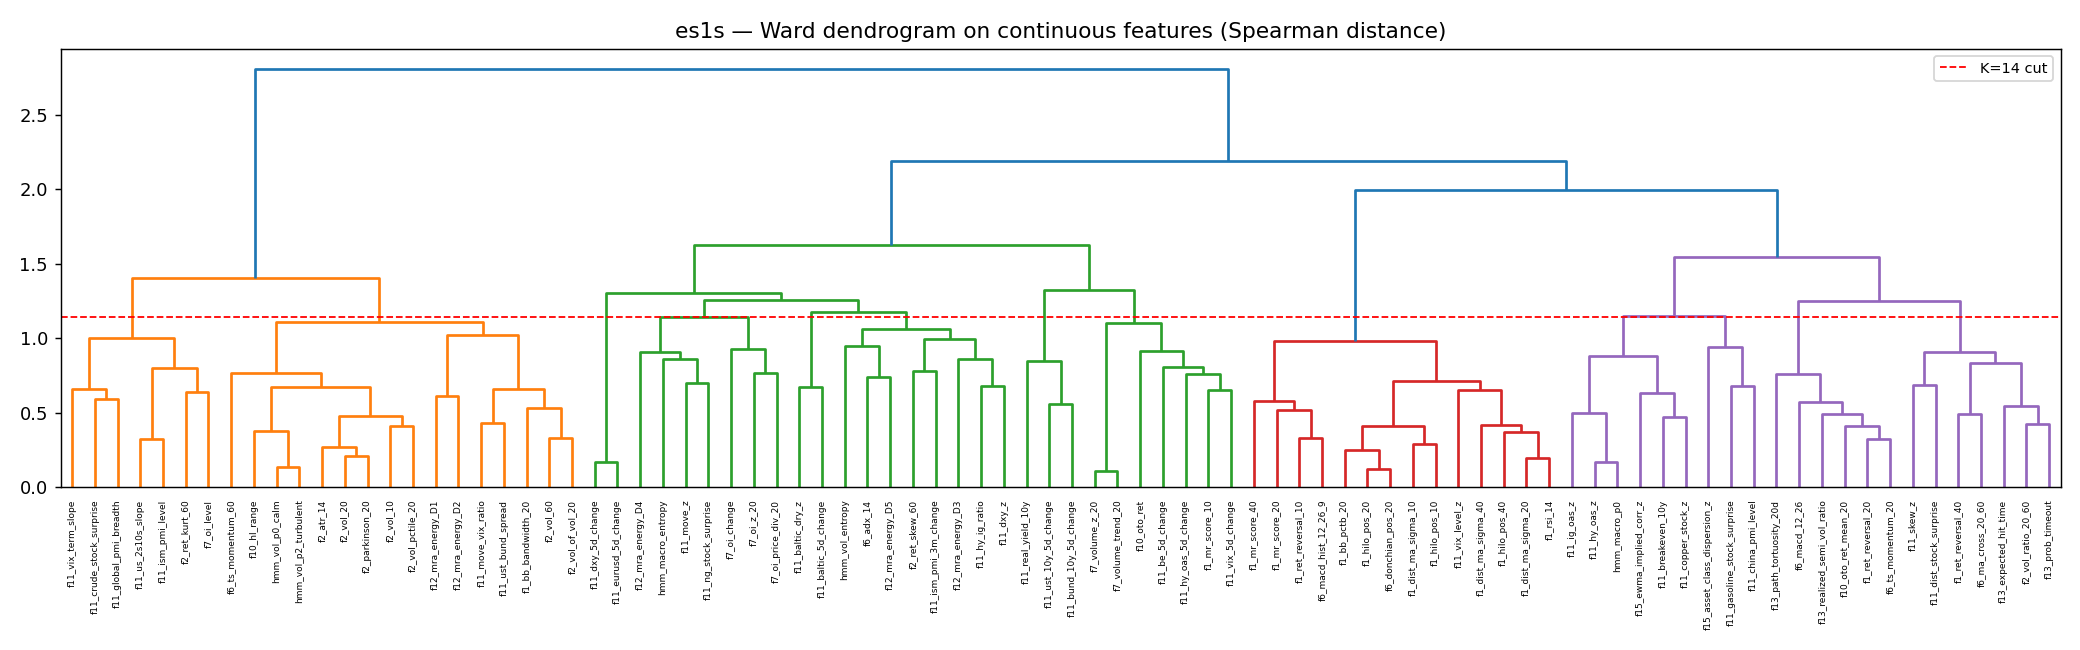

In [2]:
cs = cluster_summary('es1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.02, vmax=0.10)
    .set_caption('es1s — cluster summary (K=14 corr + 3 hand-assigned = 17 groups)')
)
show(BASE / 'es1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

Clustered MDA (dark = significant > 1σ, light = inconclusive). Cross-check with elastic-net |coef| sums (no MDI/SHAP for logistic).
Rank agreement assessed via Kendall τ; |τ| > 0.4 = agree.

In [ ]:
show(BASE / 'es1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'es1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'es1s' / 'rank_agreement.csv')
if not cc.empty:
    fmt_cols = {'mda_mean': '{:.4f}'}
    for col in ('coef_sum', 'mdi_sum', 'shap_sum'):
        if col in cc.columns:
            fmt_cols[col] = '{:.4f}'
    display(
        cc.style
        .format(fmt_cols)
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.10)
        .set_caption('es1s — cluster cross-check (MDA · Coef ranks; elastic-net logistic)')
    )
if not ra.empty:
    print('\nKendall \u03c4 rank agreement:')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))

### Step 3 · Within-cluster breakdown (top 3 by MDA)

Members ranked by mean |standardised coef| (elastic-net). PCA on train submatrix.

**C10\_f1** (short-term MR features): PC1=77.5% (single latent dim). `f1_mr_score_20` dominates by |coef| (0.088).

**C2\_f2** (HMM regime + momentum): PC1=63.7% (dominant direction). `hmm_vol_p2_turbulent` (0.102) and `hmm_vol_p0_calm` (0.093) lead — HMM regime state drives es1s.

**C8\_f11\_lowfreq\_macro** (low-frequency macro rates): PC1=69.4% (dominant direction). `f11_ust_10y_5d_change` dominates strongly (|coef|=0.224) — 5-day US 10Y yield changes are the top predictor.

In [ ]:
wc = load(BASE / 'es1s' / 'within_cluster_C10_f1.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'es1s | C10_f1 — score ranking + PC1 loadings  ({label})')
    )
show(BASE / 'es1s' / 'within_cluster_C10_f1.png', width=950)


In [ ]:
wc = load(BASE / 'es1s' / 'within_cluster_C2_f2.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'es1s | C2_f2 — score ranking + PC1 loadings  ({label})')
    )
show(BASE / 'es1s' / 'within_cluster_C2_f2.png', width=950)


In [ ]:
wc = load(BASE / 'es1s' / 'within_cluster_C8_f11_lowfreq_macro.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'es1s | C8_f11_lowfreq_macro — score ranking + PC1 loadings  ({label})')
    )
show(BASE / 'es1s' / 'within_cluster_C8_f11_lowfreq_macro.png', width=950)


### Step 5 · Global per-feature coefficient

Mean |standardised coefficient| per feature, averaged across 15 CPCV paths. Red = positive predictive direction, blue = negative.

In [ ]:
gs = load(BASE / 'es1s' / 'global_coef_summary.csv')
if not gs.empty:
    display(
        gs.head(25).style
        .format({'coef_abs': '{:.4f}', 'coef_signed': '{:.4f}'})
        .background_gradient(subset=['coef_abs'], cmap='Blues')
        .set_caption('es1s — top 25 features by mean |standardised coefficient|')
    )
show(BASE / 'es1s' / 'global_coef_chart.png', width=1000)

---
## NQ1S — champion: `nq1s` / XGB

**CPCV:** 15 paths · AUC 0.570 ± 0.033 · **SIGNAL** (lower CI 0.537)

**Significant clusters:** C8\_f11 (MDA 0.026), C1\_f1 (MDA 0.022). MDA–SHAP τ=0.52 · MDA–MDI τ=0.41 (both agree).

> nq1s uses an **XGB** champion. Two clusters clear the 1σ bar. `f11_copper_stock_z`
> (copper inventory z-score) dominates C8\_f11 by SHAP (0.050, >> others) — a commodity supply
> signal with a cross-asset link to Nasdaq direction. C1\_f1 (short-term MR) adds a secondary
> reversal signal. MDA–SHAP and MDA–MDI both agree, lending credibility to the ranking.

### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
16,F5_signal,5,f5_,100%,0.1744,0.0736,True
9,C4_f11,5,f11_,40%,0.0627,0.0499,True
13,C8_f11,9,f11_,78%,0.0124,0.0274,False
11,C6_f11,6,f11_,83%,0.0095,0.0195,False
1,C11_f11,7,f11_,57%,0.0063,0.0149,False
2,C12_f11_lowfreq_macro,2,f11_,100%,0.0057,0.0115,False
0,C10_f7,2,f7_,100%,0.0015,0.0050,False
8,C3_f6,6,f6_,33%,0.0012,0.0041,False
14,C9_f11_lowfreq_macro,3,f11_,100%,0.0005,0.0055,False
12,C7_f12,8,f12_,38%,-0.0000,0.0037,False


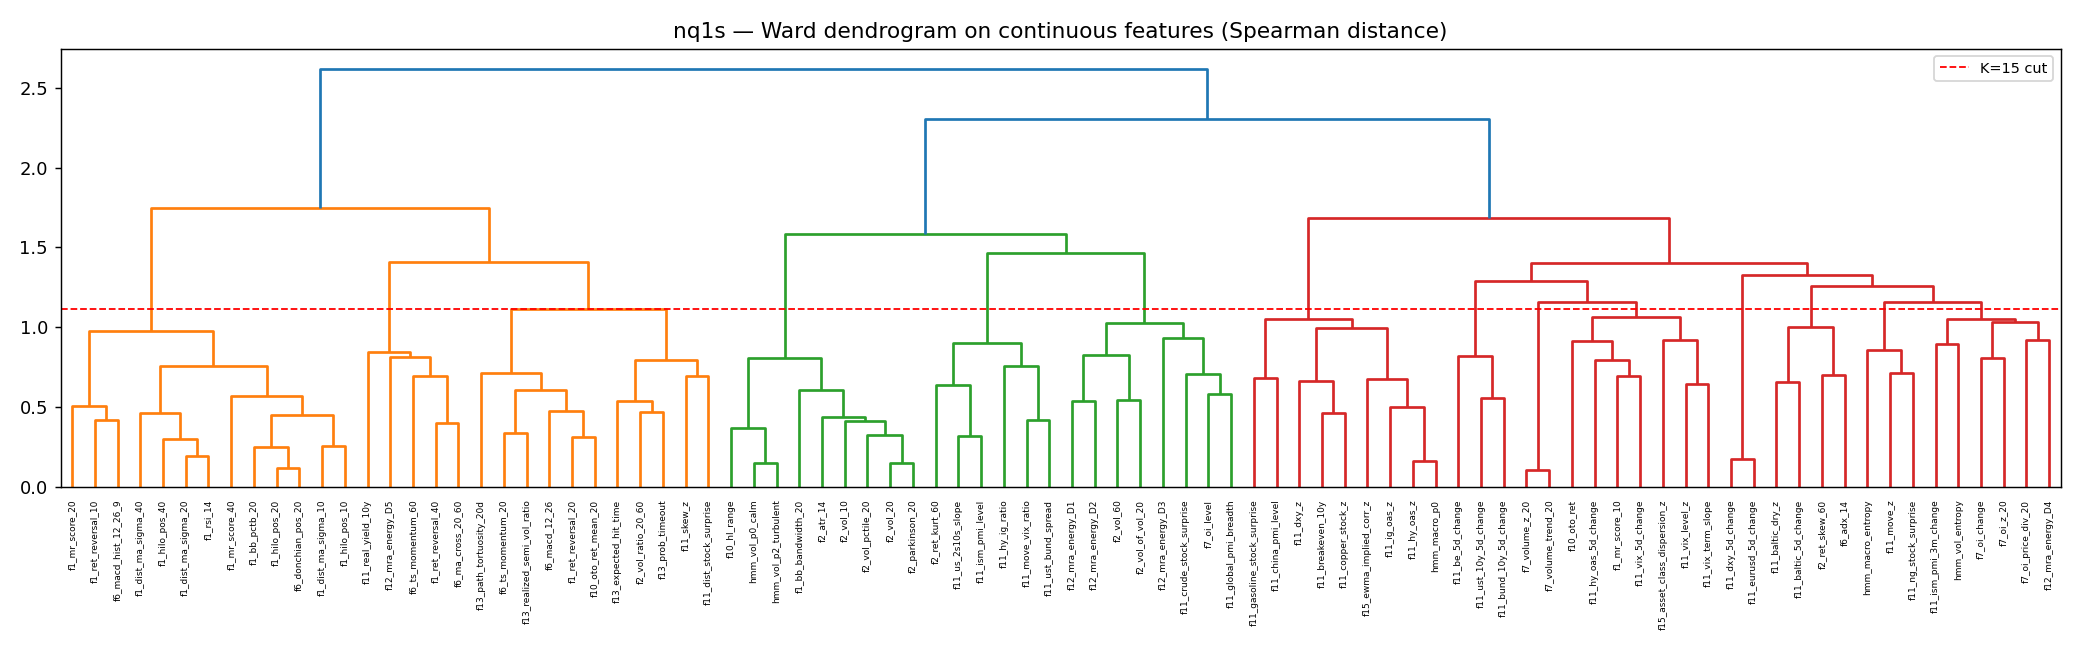

In [ ]:
cs = cluster_summary('nq1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.02, vmax=0.20)
    .set_caption('nq1s — cluster summary (K=15 corr + 3 hand-assigned = 18 groups)')
)
show(BASE / 'nq1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

Clustered MDA (dark = significant > 1σ). Cross-check with MDI and SHAP.


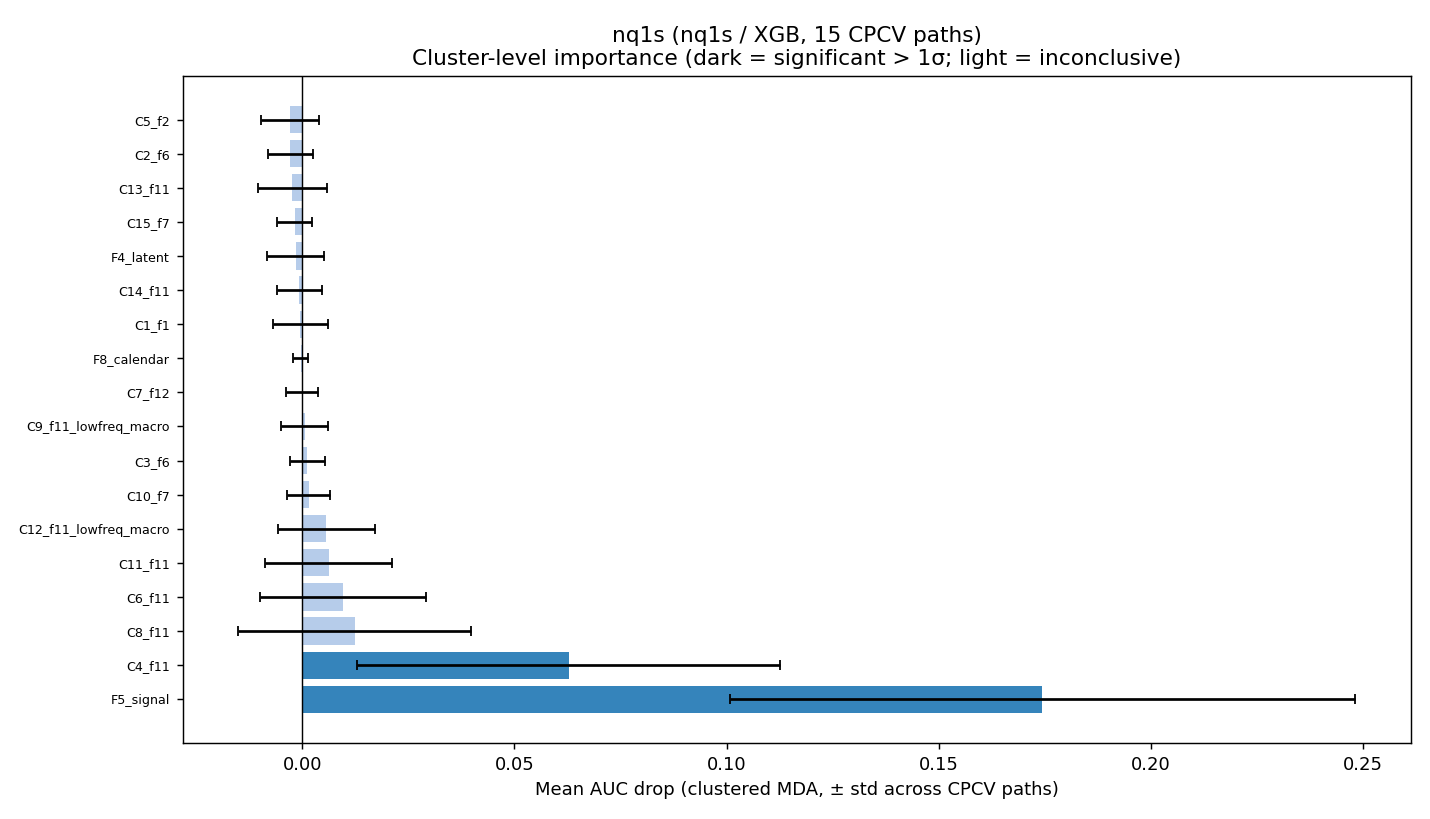

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,F5_signal,0.1744,1,0.0889,3,0.3044,1,True
1,C4_f11,0.0627,2,0.0743,5,0.0780,3,True
2,C8_f11,0.0124,3,0.1237,1,0.0969,2,False
3,C6_f11,0.0095,4,0.0777,4,0.0622,4,False
4,C11_f11,0.0063,5,0.0651,7,0.0606,5,False
5,C12_f11_lowfreq_macro,0.0057,6,0.0339,14,0.0283,7,False
6,C10_f7,0.0015,7,0.0312,15,0.0105,15,False
7,C3_f6,0.0012,8,0.0446,11,0.0076,17,False
8,C9_f11_lowfreq_macro,0.0005,9,0.0354,13,0.0213,9,False
9,C7_f12,-0.0000,10,0.0625,8,0.0201,10,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.24,False
1,MDA-SHAP,0.49,True
2,MDI-SHAP,0.59,True


In [ ]:
show(BASE / 'nq1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'nq1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'nq1s' / 'rank_agreement.csv')
if not cc.empty:
    display(
        cc.style
        .format({'mda_mean': '{:.4f}', 'mdi_sum': '{:.4f}', 'shap_sum': '{:.4f}'})
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.20)
        .set_caption('nq1s — cluster cross-check (MDA · MDI · SHAP ranks)')
    )
if not ra.empty:
    print('\nKendall \u03c4 rank agreement:')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))


### Step 3 · Within-cluster breakdown (top 3 by MDA)

Members ranked by mean |SHAP|. PCA on train submatrix.

**C8\_f11** (macro features): PC1=59.4% (dominant direction). `f11_copper_stock_z` dominates by SHAP (0.050), far above others — copper inventory z-score is the key macro signal for Nasdaq.

**C1\_f1** (short-term MR features): PC1=78.6% (single latent dim). `f1_ret_reversal_10` and `f1_hilo_pos_40` lead with similar SHAP (~0.010) — one latent reversal dimension.

**C5\_f2** (vol/range features): PC1=75.9% (single latent dim). `f10_hl_range` dominates (0.026).

In [ ]:
wc = load(BASE / 'nq1s' / 'within_cluster_C8_f11.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'nq1s | C8_f11 — score ranking + PC1 loadings  ({label})')
    )
show(BASE / 'nq1s' / 'within_cluster_C8_f11.png', width=950)


In [ ]:
wc = load(BASE / 'nq1s' / 'within_cluster_C1_f1.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'nq1s | C1_f1 — score ranking + PC1 loadings  ({label})')
    )
show(BASE / 'nq1s' / 'within_cluster_C1_f1.png', width=950)


In [ ]:
wc = load(BASE / 'nq1s' / 'within_cluster_C5_f2.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'nq1s | C5_f2 — score ranking + PC1 loadings  ({label})')
    )
show(BASE / 'nq1s' / 'within_cluster_C5_f2.png', width=950)


### Step 5 · Global per-feature SHAP

Mean |SHAP| per feature, averaged across 15 CPCV paths on nq1s. Red = positive, blue = negative.


,feature,shap_magnitude,shap_signed,mdi
0,f5_signal,0.2978,0.0820,0.0636
1,f11_dist_stock_surprise,0.0609,-0.0118,0.0365
2,f11_copper_stock_z,0.0390,0.0111,0.0252
3,f11_vix_5d_change,0.0333,0.0099,0.0256
4,f11_gasoline_stock_surprise,0.0254,-0.0007,0.0216
5,f11_move_vix_ratio,0.0246,-0.0084,0.0204
6,f11_dxy_5d_change,0.0230,-0.0025,0.0192
7,f11_be_5d_change,0.0174,0.0071,0.0201
8,f11_hy_ig_ratio,0.0151,0.0020,0.0128
9,f11_breakeven_10y,0.0132,0.0018,0.0185


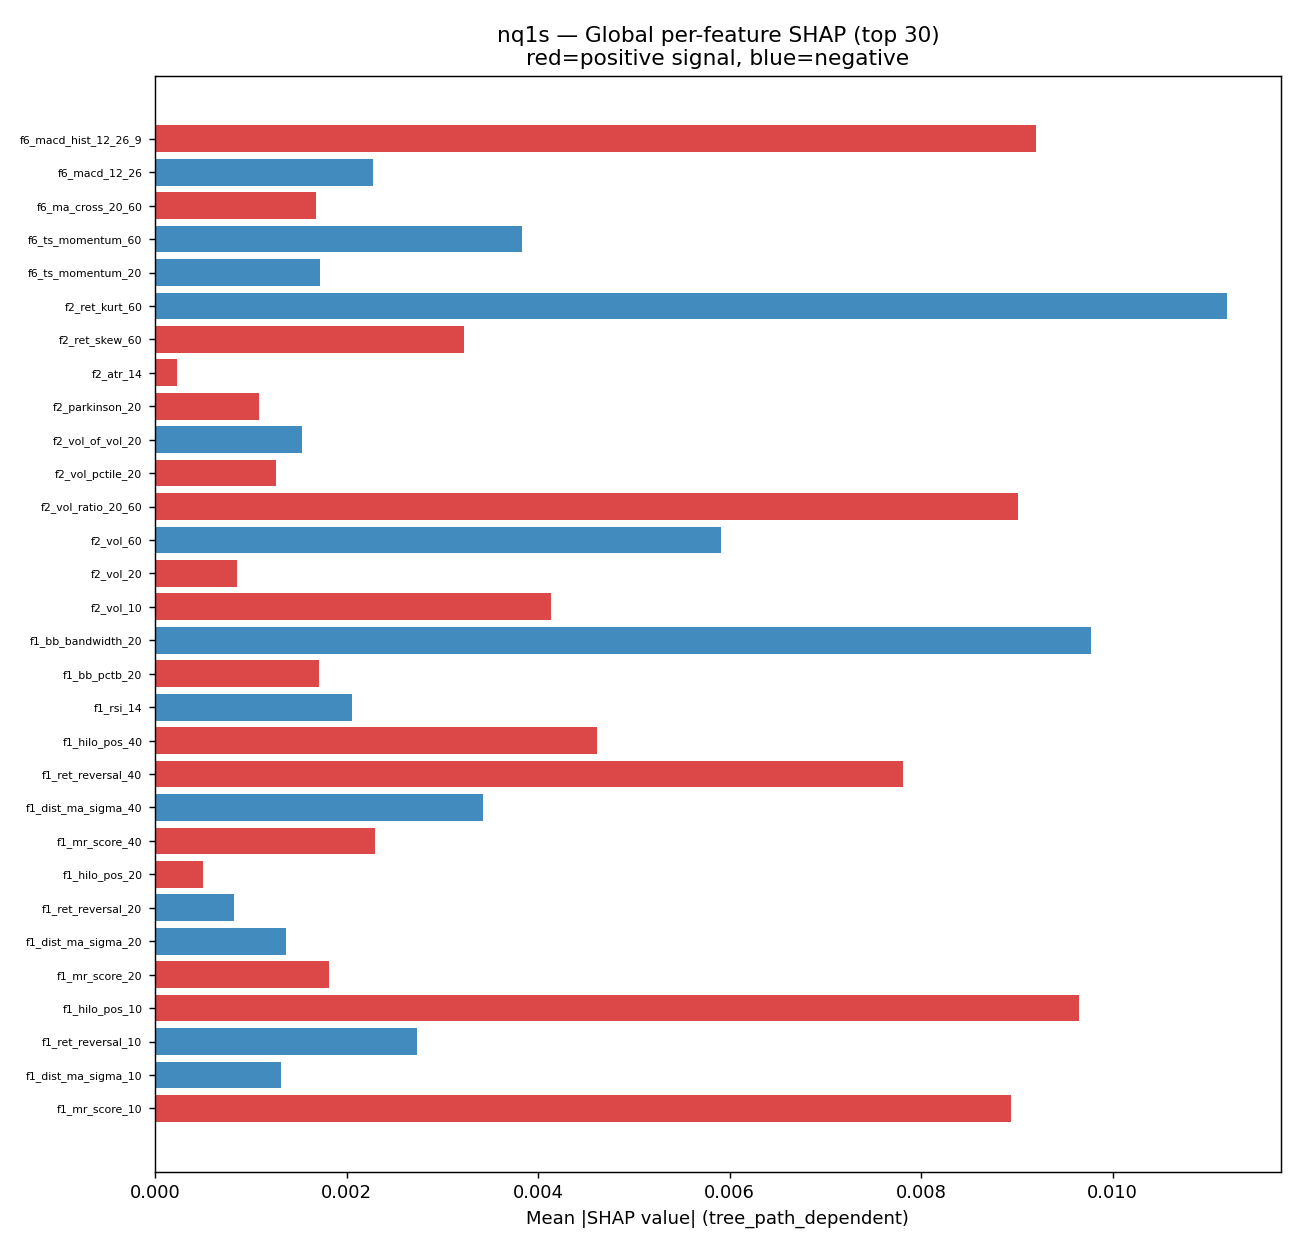

In [ ]:
gs = load(BASE / 'nq1s' / 'global_shap_summary.csv')
if not gs.empty:
    display(
        gs.head(25).style
        .format({'shap_magnitude': '{:.4f}', 'shap_signed': '{:.4f}', 'mdi': '{:.4f}'})
        .background_gradient(subset=['shap_magnitude'], cmap='Blues')
        .set_caption('nq1s — top 25 features by mean|SHAP|')
    )
show(BASE / 'nq1s' / 'global_shap_chart.png', width=1000)


---
## FESX1S — champion: `fesx1s` / RF

**CPCV:** 15 paths · AUC 0.496 ± 0.024 · **NO SIGNAL** (lower CI 0.472)

**Significant clusters:** none. MDA–MDI τ=0.10 · MDA–SHAP τ=0.12 (neither agrees; MDI–SHAP τ=0.92 = internal tree coherence only).

> fesx1s uses a **random forest** champion with **no confirmed signal** (lower CI < 0.50).
> No cluster clears the 1σ MDA bar. The importance analysis is included for structural contrast —
> results reflect model noise rather than exploitable predictability. The disagreement between MDA
> and SHAP/MDI rankings (τ < 0.15) further undermines confidence in the feature ordering.

### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
16,F5_signal,5,f5_,100%,0.0652,0.0409,True
0,C10_f12,4,f12_,75%,0.0199,0.0257,False
3,C13_f7,3,f7_,100%,0.0074,0.0081,False
8,C3_f6,8,f6_,50%,0.0072,0.0174,False
6,C1_f2,16,f2_,44%,0.0065,0.0217,False
11,C6_f11,7,f11_,71%,0.0059,0.0130,False
9,C4_f11,7,f11_,57%,0.0047,0.0099,False
13,C8_f11,7,f11_,71%,0.0044,0.0151,False
10,C5_f11,5,f11_,80%,0.0017,0.0131,False
2,C12_f11_lowfreq_macro,3,f11_,100%,0.0017,0.0114,False


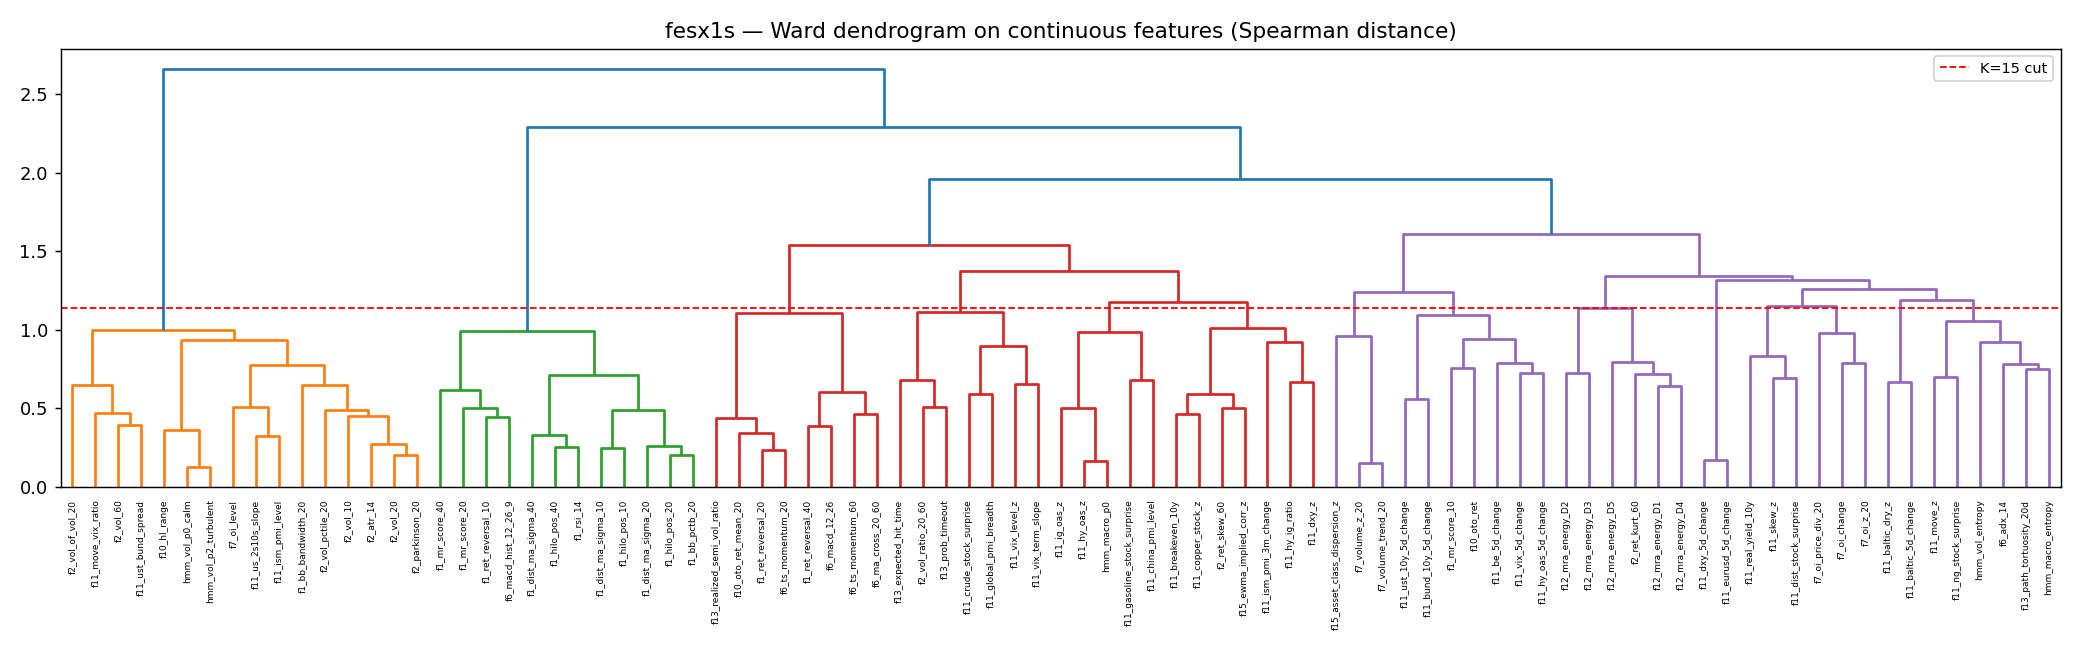

In [ ]:
cs = cluster_summary('fesx1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.02, vmax=0.08)
    .set_caption('fesx1s — cluster summary (K=15 corr + 3 hand-assigned = 18 groups)')
)
show(BASE / 'fesx1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

Clustered MDA (dark = significant > 1σ). Cross-check with MDI and SHAP (random forest).
Rank agreement assessed via Kendall τ; |τ| > 0.4 = agree.

In [ ]:
show(BASE / 'fesx1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'fesx1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'fesx1s' / 'rank_agreement.csv')
if not cc.empty:
    fmt_cols = {'mda_mean': '{:.4f}'}
    for col in ('mdi_sum', 'shap_sum', 'coef_sum'):
        if col in cc.columns:
            fmt_cols[col] = '{:.4f}'
    display(
        cc.style
        .format(fmt_cols)
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.08)
        .set_caption('fesx1s — cluster cross-check (MDA · MDI · SHAP ranks; RF)')
    )
if not ra.empty:
    print('\nKendall \u03c4 rank agreement (MDA vs MDI vs SHAP):')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))

### Step 3 · Within-cluster breakdown (top 3 by MDA)

Members ranked by mean |SHAP|. PCA on train submatrix. No clusters are significant — all results are illustrative only.

**C2\_f1** (short-term MR features): PC1=75.0% (single latent dim). `f1_hilo_pos_40` leads by SHAP (0.005). Weak signal, consistent with no confirmed predictability.

**C15\_f11** (macro + regime features): PC1=28.4% (genuinely multi-dimensional). `hmm_vol_entropy`, `f11_ng_stock_surprise`, and `f13_path_tortuosity_20d` spread across independent axes — no single macro dimension dominates.

**F5\_signal** — 4-PC PCA described in cell below.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- load fesx1s train events (descriptive; fits PCA on train rows only) ---
_ev = pd.read_parquet(
    BASE.parent / 'model_comparison' / '_cache' / 'fesx1s_events.parquet'
)
F5_MEMBERS = [
    'f5_signal', 'f5_trailing_run_length', 'f5_participation_20',
    'f5_long_bias_20', 'f5_sign_agree_mr',
]
_X = _ev[F5_MEMBERS].dropna()

_sc  = StandardScaler()
_pca = PCA(n_components=4, random_state=42)
_pca.fit(_sc.fit_transform(_X))

# --- variance-explained table ---
_var  = _pca.explained_variance_ratio_
_cum  = _var.cumsum()
_var_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(4)],
    'Var explained': _var,
    'Cumulative':    _cum,
})
display(
    _var_df.style
    .format({'Var explained': '{:.1%}', 'Cumulative': '{:.1%}'})
    .background_gradient(subset=['Var explained'], cmap='Blues')
    .set_caption('fesx1s | F5_signal — PCA variance explained (train, descriptive)')
    .hide(axis='index')
)

# --- loadings matrix (members × PCs) ---
_load = pd.DataFrame(
    _pca.components_.T,
    index=F5_MEMBERS,
    columns=[f'PC{i+1}' for i in range(4)],
)
# attach mean |score| for reference
_wc = load(BASE / 'fesx1s' / 'within_cluster_F5_signal.csv')
if not _wc.empty:
    _score_col = 'mean_shap_mag' if 'mean_shap_mag' in _wc.columns else 'mean_coef_abs'
    _load.insert(0, '|score|', _wc.set_index('feature')[_score_col].reindex(F5_MEMBERS).values)
display(
    _load.style
    .format({'|score|': '{:.4f}', **{f'PC{i+1}': '{:+.3f}' for i in range(4)}})
    .background_gradient(subset=[f'PC{i+1}' for i in range(4)], cmap='RdBu_r', vmin=-1, vmax=1)
    .set_caption('fesx1s | F5_signal — loadings matrix (rows=members, cols=PCs)')
)

# --- PC interpretations ---
_interp = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(4)],
    'Var': [f'{v:.1%}' for v in _var],
    'Cumul': [f'{c:.1%}' for c in _cum],
    'Dominant features': [
        'f5_long_bias_20 (+0.63), f5_trailing_run_length (+0.53), f5_signal (+0.49)',
        'f5_sign_agree_mr (+0.94)  — all others near zero',
        'f5_participation_20 (+0.92)  — participation rate in isolation',
        'f5_signal (+0.68) vs f5_trailing_run_length (−0.64)',
    ],
    'Interpretation': [
        'Sustained signal / long-bias momentum: signal on + running + high participation',
        'MR–signal agreement: sign-agree-mr captures when signal & mean-reversion align',
        'Participation-rate isolate: high turnover independent of signal direction',
        'Fresh-signal divergence: signal fires but run length is short (or vice versa)',
    ],
})
display(
    _interp.style
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .hide(axis='index')
    .set_caption('fesx1s | F5_signal — PC interpretations')
)

# keep original image
show(BASE / 'fesx1s' / 'within_cluster_F5_signal.png', width=950)


In [ ]:
wc = load(BASE / 'fesx1s' / 'within_cluster_C2_f1.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'fesx1s | C2_f1 — score ranking + PC1 loadings  ({label})')
    )
show(BASE / 'fesx1s' / 'within_cluster_C2_f1.png', width=950)


In [ ]:
wc = load(BASE / 'fesx1s' / 'within_cluster_C15_f11.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'fesx1s | C15_f11 — score ranking + PC1 loadings  ({label})')
    )
show(BASE / 'fesx1s' / 'within_cluster_C15_f11.png', width=950)


### Step 5 · Global per-feature SHAP

Mean |SHAP| per feature, averaged across 15 CPCV paths on fesx1s. Red = positive, blue = negative.
Note: fesx1s carries no confirmed signal — results are illustrative only.

In [ ]:
gs = load(BASE / 'fesx1s' / 'global_shap_summary.csv')
if not gs.empty:
    display(
        gs.head(25).style
        .format({'shap_magnitude': '{:.4f}', 'shap_signed': '{:.4f}', 'mdi': '{:.4f}'})
        .background_gradient(subset=['shap_magnitude'], cmap='Blues')
        .set_caption('fesx1s — top 25 features by mean|SHAP| (NO SIGNAL — illustrative only)')
    )
show(BASE / 'fesx1s' / 'global_shap_chart.png', width=1000)

---
## Cross-instrument findings — equity

Structured summary across es1s, nq1s, fesx1s.


In [ ]:
EQUITY_INSTS = ['es1s', 'nq1s', 'fesx1s']
NOSIGNAL = {'fesx1s'}

rows = []
for inst in EQUITY_INSTS:
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    ra  = load(BASE / inst / 'rank_agreement.csv')
    meta = load(BASE / inst / 'champion_meta.csv')
    if mda.empty:
        continue
    top = mda.iloc[0]
    sig_count = int(mda['significant'].sum())
    tau_1 = ra['kendall_tau'].iloc[0] if not ra.empty else float('nan')
    champion = meta['model_type'].iloc[0].upper() if not meta.empty else '?'
    signal = meta['signal'].iloc[0] if not meta.empty else False
    rows.append({
        'inst': inst,
        'champion': champion,
        'signal': '\u2713' if signal else '\u2717',
        'n_sig_clusters': sig_count,
        'top_cluster': top['cluster'],
        'top_mda': round(top['mean_drop'], 4),
        'tau_primary': round(tau_1, 2) if not pd.isna(tau_1) else 'n/a',
    })

summary = pd.DataFrame(rows).set_index('inst')
display(
    summary.style
    .set_caption('Equity champions — cross-instrument summary')
)


In [ ]:
# Top cluster per instrument — MDA ranking
for inst in EQUITY_INSTS:
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mda.empty:
        continue
    label = '(NO SIGNAL)' if inst in NOSIGNAL else ''
    print(f'\n{inst.upper()} {label}')
    print(mda[['cluster', 'mean_drop', 'std_drop', 'significant']].head(5).to_string(index=False))



ES1S (NO SIGNAL)
             cluster  mean_drop  std_drop  significant
           F5_signal   0.082743  0.034326         True
             C14_f11   0.018487  0.055049        False
               C2_f2   0.012213  0.022583        False
C3_f11_lowfreq_macro   0.000302  0.003531        False
               C5_f7  -0.000702  0.014617        False

NQ1S 
  cluster  mean_drop  std_drop  significant
F5_signal   0.174369  0.073602         True
   C4_f11   0.062736  0.049908         True
   C8_f11   0.012351  0.027398        False
   C6_f11   0.009525  0.019517        False
  C11_f11   0.006271  0.014944        False

FESX1S 
  cluster  mean_drop  std_drop  significant
F5_signal   0.065201  0.040913         True
  C10_f12   0.019913  0.025659        False
   C13_f7   0.007406  0.008142        False
    C3_f6   0.007189  0.017425        False
    C1_f2   0.006460  0.021692        False


### Key observations

**es1s (logistic, SIGNAL)**: Three clusters clear the 1σ bar — short-term MR (C10\_f1), HMM regime + momentum (C2\_f2), and low-frequency macro rates (C8\_f11\_lowfreq\_macro). `f11_ust_10y_5d_change` is the dominant feature by |coef| (0.224). MDA–Coef agree (τ=0.56).

**nq1s (XGB, SIGNAL)**: Two significant clusters — C8\_f11 (macro) and C1\_f1 (short-term MR). `f11_copper_stock_z` (copper inventory z-score) dominates C8\_f11 by SHAP (0.050, >> others) — a commodity supply signal cross-linked to Nasdaq. MDA–SHAP τ=0.52, MDA–MDI τ=0.41 (both agree).

**fesx1s (RF, NO SIGNAL)**: No clusters significant; MDA–SHAP rankings disagree (τ=0.12). Results included for structural contrast only — the model captures noise, not exploitable structure.

**Cross-instrument**: Short-term mean-reversion features (f1 prefix) appear in the top-3 clusters for all three instruments. The strength of macro cross-asset signals varies: 10Y yield changes dominate es1s; copper inventory z-score dominates nq1s; fesx1s shows no reliable pattern.